# Circle Simulation

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from geomstats.geometry.hypersphere import Hypersphere

INFO: Using numpy backend


In [2]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Setting Up

In [3]:
dim = 1
circle = Hypersphere(dim)

In [4]:
mean1 = np.array([1./np.sqrt(2), 1./np.sqrt(2)])
mean2 = -mean1
tau2 = 0.5
    
def sample_G(n_samples): 
    classes = np.random.randint(0,2,n_samples).reshape(-1,1)
    samples1 = circle.random_riemannian_normal(mean1, 1./tau2, n_samples)
    samples2 = circle.random_riemannian_normal(mean2, 1./tau2, n_samples)
    return classes*samples1 + (1-classes)*samples2

In [5]:
n = 1000
sigma2 = 0.5

In [6]:
Theta = sample_G(n)
X = circle.random_riemannian_normal(Theta, 1./sigma2, n)
Theta_angs = circle.extrinsic_to_intrinsic_coords(Theta).ravel()
X_angs = circle.extrinsic_to_intrinsic_coords(X).ravel()

Text(0.5, 1.0, '$X_i$')

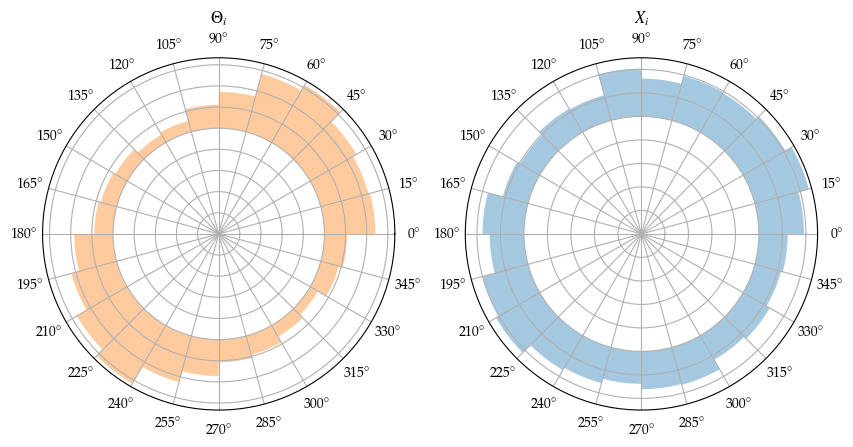

In [7]:
fig = plt.figure(figsize=(10,5))
ax = [None] * 2


incr = 15
bottom = 0.5
angs = np.radians(np.arange(0, 360, incr))
width = np.radians(incr)


ax[0] = fig.add_subplot(121, polar=True)
Theta_freqs, _ = np.histogram(Theta_angs,int(360/incr), density=True)
ax[0].bar(angs, Theta_freqs, width=width, color='C1', alpha=0.4, align='edge',bottom=bottom)
ax[0].set_xticks(angs)
ax[0].set_yticklabels([])
ax[0].set_title('$\\Theta_i$')


ax[1] = fig.add_subplot(122, polar=True)
X_freqs, _ = np.histogram(X_angs,int(360/incr), density=True)
ax[1].bar(angs, X_freqs, width=width, color='C0', alpha=0.4, align='edge',bottom=bottom)
ax[1].set_xticks(angs)
ax[1].set_yticklabels([])
ax[1].set_title('$X_i$')

## Density Estimation

In [8]:
def density_estimate(x_angs, K):
    out = np.zeros(shape=x_angs.shape, dtype='complex128')
    for i in range(X.shape[0]):
        for k in range(-K,K+1):
            out += np.exp(1j*k*(x_angs - X_angs[i]))
    return np.real(out)/(np.sqrt(2*np.pi)*X.shape[0])

In [9]:
K = 3
res = 150

x_angs = np.linspace(0, 2*np.pi, res)
hat_f = density_estimate(x_angs, K)

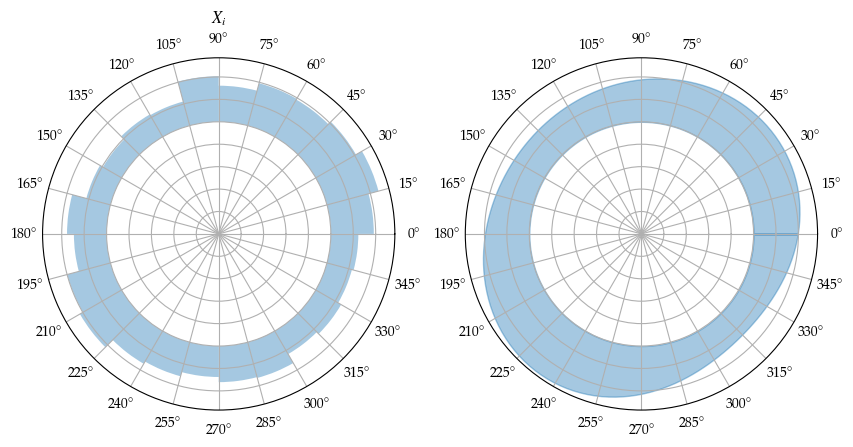

In [10]:
fig = plt.figure(figsize=(10,5))
ax = [None] * 2

ax[0] = fig.add_subplot(121, polar=True)

ax[0].bar(angs, X_freqs, width=width, color='C0', alpha=0.4, align='edge',bottom=bottom)
ax[0].set_xticks(angs)
ax[0].set_yticklabels([])
ax[0].set_title('$X_i$')

f_scale = 0.5
ax[1] = fig.add_subplot(122, polar=True)
# ax[1].plot(x_angs, bottom+f_scale*hat_f, color='C0', alpha=0.8)
ax[1].fill_between(x_angs, bottom*np.ones_like(x_angs),bottom+f_scale*hat_f, color='C0', alpha=0.4)
ax[1].set_yticklabels([])
ax[1].set_xticks(angs)
ax[0].sharey(ax[1])

## Empirical Bayes denoising

In [11]:
def denoiser(x_angs, K, rho):
    
    # estimate f
    hat_f = density_estimate(x_angs, K)
    
    # estimate grad f
    hat_grad_f_angs = np.zeros(shape=x_angs.shape,dtype='complex128')
    for k in range(-K,K+1):
        for i in range(X.shape[0]):
            hat_grad_f_angs += 1j*k*np.exp(1j*k*(x_angs - X_angs[i]))
    hat_grad_f_angs = np.real(hat_grad_f_angs)/(np.sqrt(2*np.pi) * X.shape[0])
                
                    
    # compute score function
    hat_score_angs = hat_grad_f_angs / np.maximum(hat_f, rho)

    # compute denoiser
    delta_angs = np.zeros_like(x_angs)
    for i in range(X.shape[0]):
        delta_angs[i] = X_angs[i] + sigma2 * hat_score_angs[i]
    delta = np.asarray([np.cos(delta_angs),np.sin(delta_angs)]).T

    return delta

In [12]:
rho = 0.05
delta = denoiser(X_angs, K, rho)

Text(0.5, 1.0, '$\\hat{\\delta}_T(X_i)$')

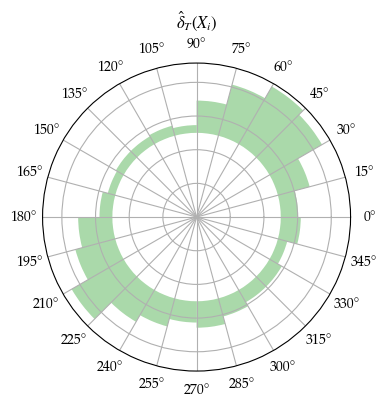

In [13]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, polar=True)

delta_angs = circle.extrinsic_to_intrinsic_coords(delta)
delta_freqs, _ = np.histogram(delta_angs,int(360/incr), density=True)
ax.bar(angs, delta_freqs, width=width, color='C2', alpha=0.4, align='edge',bottom=bottom)
ax.set_xticks(angs)
ax.set_yticklabels([])
ax.set_title('$\\hat{\\delta}_T(X_i)$')

## Plotting

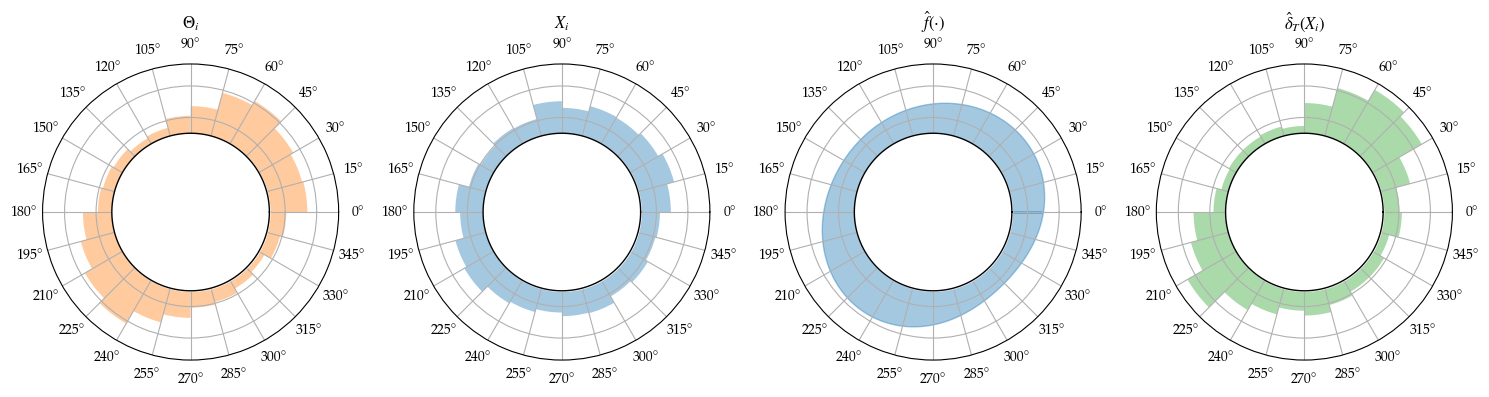

In [14]:
fig = plt.figure(figsize=(15,4))
ax = [None] * 4

for m in range(4):
    ax[m] = fig.add_subplot(1, 4, m+1, polar=True)
    ax[m].set_xticks(angs)
    ax[m].set_yticklabels([])
    ax[m].plot(x_angs, bottom*np.ones_like(x_angs), color='black', linewidth=1., zorder=5)
    ax[m].fill_between(x_angs, np.zeros_like(x_angs), bottom*np.ones_like(x_angs), color='white', zorder=4)
    # ax[m].set_rmin(bottom)
    # ax[m].set_rorigin(bottom)

    
ax[0].bar(angs, Theta_freqs, width=width, color='C1', alpha=0.4, align='edge',bottom=bottom)
ax[0].set_title('$\\Theta_i$')

ax[1].bar(angs, X_freqs, width=width, color='C0', alpha=0.4, align='edge',bottom=bottom)
ax[1].set_title('$X_i$')

ax[2].fill_between(x_angs, bottom*np.ones_like(x_angs),bottom+f_scale*hat_f, color='C0', alpha=0.4)
ax[2].set_title('$\\hat{f}(\cdot)$')

ax[3].bar(angs, delta_freqs, width=width, color='C2', alpha=0.4, align='edge',bottom=bottom)
ax[3].set_title('$\\hat{\\delta}_T(X_i)$')

for m in range(4):
    if m != 2: ax[m].sharey(ax[2])
plt.tight_layout()

plt.savefig('circle_sim.pdf')